In [1]:
#-----------------------------
# Packages Import
#-----------------------------
#%matplotlib inline

# numpy and Matplotlib 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
 
# torch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Used to handle picture drawings
import cv2

# Used Handle directories and paths
import os

# Used to create and compute random angles
import random
import math

# Used to create the image labels
import json


# Pytorch image functions
import torchvision
from torchvision.transforms import v2
from torchvision.io import decode_image
from torchvision.io import read_image


# Dataloader and Data functions
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

In [2]:
#--------------------------
# Constants across the project
#----------------------------

# Crossing type mappings (5 classes: overcrossing, undercrossing, line, empty, full)
CROSSING_TO_IDX = {"overcrossing": 0, "undercrossing": 1, "line": 2, "empty": 3, "full": 4}
IDX_TO_CROSSING = {v: k for k, v in CROSSING_TO_IDX.items()}

# Image window and dot channel parameters
WINDOW_SIZE = (64, 64)



In [3]:
# current working directory
path = os.getcwd()
# data directory
DATA_DIR = os.path.join(path, os.pardir,'data','local_Knot_training_data')

In [4]:
#--------------------------------------------
# Transformations for training data
#--------------------------------------------


# Rotation around a center to make the data more real
def RotationalTwist(gray_np, max_twist=0.03):   
        if isinstance(gray_np, torch.Tensor):
            gray_np = gray_np.numpy().transpose(1, 2, 0)

        h, w = gray_np.shape[:2]
        cx, cy = w // 2, h // 2
        
        # Create a coordinate grid
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        
        # Shift origin to center
        x_c = x - cx
        y_c = y - cy
        
        # Calculate radius and angle for every pixel
        r = np.sqrt(x_c**2 + y_c**2)
        theta = np.arctan2(y_c, x_c)
        
        # Apply the twist: angle changes based on radius
        # (Randomize the strength so every image is different)
        strength = np.random.uniform(-max_twist, max_twist)
        new_theta = theta + strength * r
        
        # Map back to Cartesian coordinates
        map_x = cx + r * np.cos(new_theta)
        map_y = cy + r * np.sin(new_theta)
        
        # Remap the image pixels to the new grid
        twisted = cv2.remap(gray_np.astype(np.float32), 
                           map_x.astype(np.float32), 
                           map_y.astype(np.float32), 
                           cv2.INTER_LINEAR)
        
        # Return as tensor
        if len(twisted.shape) == 2: # Keep 1-channel shape
            twisted = twisted[:, :, np.newaxis]
        return torch.from_numpy(twisted.transpose(2, 0, 1))
    
    

# Grayscale augmentation, applied only to Channel 1 (grayscale) before Sobel computation
def grayscale_augment(gray_np):
    """
    Light augmentation on grayscale channel only.
    gray_np: float32 [H, W] in [0, 1]
    Returns: float32 [H, W] in [0, 1]
    """
    # Random brightness shift
    gray_np = gray_np + np.random.uniform(-0.05, 0.05)
    gray_np = np.clip(gray_np, 0.0, 1.0)
    # Random Gaussian blur (simulates focus variation)
    sigma = np.random.uniform(0.1, 1.5)
    gray_np = cv2.GaussianBlur(gray_np, (3, 3), sigma)
    
    return gray_np.astype(np.float32)


# Define the augmentation pipeline
train_transforms = v2.Compose([
    #grayscale_augment,
    # Change to tensor
   # v2.ToDtype(torch.float32, scale=True), # This also normalizes 0-255 to 0-1!
    
    # Make twist with OpenCV
    RotationalTwist,

    # Geometric Augmentation (The "Jitter")
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)), # Shift and zoom
       
    # 4. Final resize just in case
    v2.Resize((64, 64), antialias=True),  
])    

In [5]:
#-------------------
#Channel helpers
#-------------------

DOT_RADIUS_FROM_CENTER = 22   # pixels from center for direction dot
DOT_DRAW_RADIUS = 3           # radius of the drawn dot circle

def make_dot_channel(angle, window_size=WINDOW_SIZE):
    """
    Creates a dot image with a small filled circle at
    (cx + r*cos(angle), cy + r*sin(angle)) from center.
    This will be a channel for the NN
    Returns: float32 [H, W] with values in [0, 1]
    """
    dot_img = np.zeros(window_size, dtype=np.float32)
    cx, cy = window_size[1] // 2, window_size[0] // 2
    dot_x = int(round(cx + DOT_RADIUS_FROM_CENTER * math.cos(angle)))
    dot_y = int(round(cy + DOT_RADIUS_FROM_CENTER * math.sin(angle)))
    dot_x = max(DOT_DRAW_RADIUS, min(window_size[1] - DOT_DRAW_RADIUS - 1, dot_x))
    dot_y = max(DOT_DRAW_RADIUS, min(window_size[0] - DOT_DRAW_RADIUS - 1, dot_y))
    cv2.circle(dot_img, (dot_x, dot_y), DOT_DRAW_RADIUS, 1.0, -1)
    return dot_img  # [H, W] float32


SOBEL_THRESHOLD = 0.05  # suppress gradients weaker than this magnitude

def compute_sobel_channels(gray_np):
    """
    Computes Sobel X and Y gradient channels from a grayscale numpy array.
    gray_np: float32 [H, W] with values in [0, 1]
    Returns: (sobel_x, sobel_y), each float32 [H, W] approximately in [-1, 1]

    Small gradients (magnitude < SOBEL_THRESHOLD) are zeroed out so that
    only strong edges (strand boundaries) contribute signal.
    """
    gray_u8 = (gray_np * 255).astype(np.uint8)
    sobel_x = cv2.Sobel(gray_u8, cv2.CV_32F, 1, 0, ksize=3) / 1020.0
    sobel_y = cv2.Sobel(gray_u8, cv2.CV_32F, 0, 1, ksize=3) / 1020.0

    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    mask = magnitude > SOBEL_THRESHOLD
    sobel_x *= mask
    sobel_y *= mask

    return sobel_x, sobel_y

In [6]:
# Load train and validation label files
with open(os.path.join(DATA_DIR, "labels_train.json"), "r") as f:
    train_data = json.load(f)

with open(os.path.join(DATA_DIR, "labels_val.json"), "r") as f:
    val_data = json.load(f)

print(f"Loaded {len(train_data)} train samples and {len(val_data)} val samples")


Loaded 12800 train samples and 3200 val samples


In [7]:
#-----------------------------------------------
# KnotDataset: 4-channel input, dual-head labels
#-----------------------------------------------

class KnotDataset(Dataset):
    """
    Returns (image_tensor [4, 64, 64], angle_label float32, crossing_label long).

    Channel layout:
      Ch1: Grayscale image, normalized to [-1, 1]
      Ch2: Dot channel (direction indicator), normalized to [-1, 1]
      Ch3: Sobel X gradient, scaled by 5.0
      Ch4: Sobel Y gradient, scaled by 5.0

    Angle head target: continuous float in [-pi, pi]
    Crossing head target: integer index in {0..4}
    """
    def __init__(self, data, img_dir, transform=None):
        self.data = data          # list of label dicts from JSON
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        img_path = os.path.join(self.img_dir, entry["filename"])

        # Channel 1: grayscale float32 [0, 1]
        gray_tensor = read_image(img_path).float() / 255.0   # [C, H, W] in [0, 1]
        gray_np = gray_tensor[0].numpy()                      # [H, W]

        # Optional augmentation on Ch1 only, before Sobel computation
        if self.transform:
            gray_np = self.transform(gray_np)
            gray_np = gray_np.squeeze(0).numpy()
            gray_np = gray_np.astype(np.float32)

        # Channel 2: dot image deterministic from stored angle
        angle = entry["angle_rad"]
        dot_np = make_dot_channel(angle)          # [H, W] float32

        # Channels 3 & 4: Sobel gradients
        sobel_x, sobel_y = compute_sobel_channels(gray_np)

        # Stack into [4, H, W] tensor
        ch1 = torch.from_numpy(gray_np).unsqueeze(0)    # [1, H, W]
        ch2 = torch.from_numpy(dot_np).unsqueeze(0)     # [1, H, W]
        ch3 = torch.from_numpy(sobel_x).unsqueeze(0)    # [1, H, W]
        ch4 = torch.from_numpy(sobel_y).unsqueeze(0)    # [1, H, W]
        image_tensor = torch.cat([ch1, ch2, ch3, ch4], dim=0)   # [4, H, W]

        # Normalize per channel
        image_tensor[0] = (image_tensor[0] - 0.5) / 0.5    # -> [-1, 1]
        image_tensor[1] = (image_tensor[1] - 0.5) / 0.5    # -> [-1, 1]
        image_tensor[2] = image_tensor[2] * 5.0              # Sobel: scale to comparable range
        image_tensor[3] = image_tensor[3] * 5.0

        # Labels
        angle_label    = torch.tensor(angle,                  dtype=torch.float32)
        crossing_label = torch.tensor(entry["crossing_idx"],  dtype=torch.long)

        return image_tensor, angle_label, crossing_label


In [8]:
#----------------------------------------
# Prepare train and validation DataLoaders
#----------------------------------------

BATCH_SIZE = 64

train_dataset = KnotDataset(train_data, DATA_DIR, transform=train_transforms)
val_dataset   = KnotDataset(val_data,   DATA_DIR, transform=None)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dataloader)}  |  Val batches: {len(val_dataloader)}")


Train batches: 200  |  Val batches: 50


Image batch shape:    torch.Size([64, 4, 64, 64])
Angle labels shape:   torch.Size([64])
Crossing labels shape:torch.Size([64])


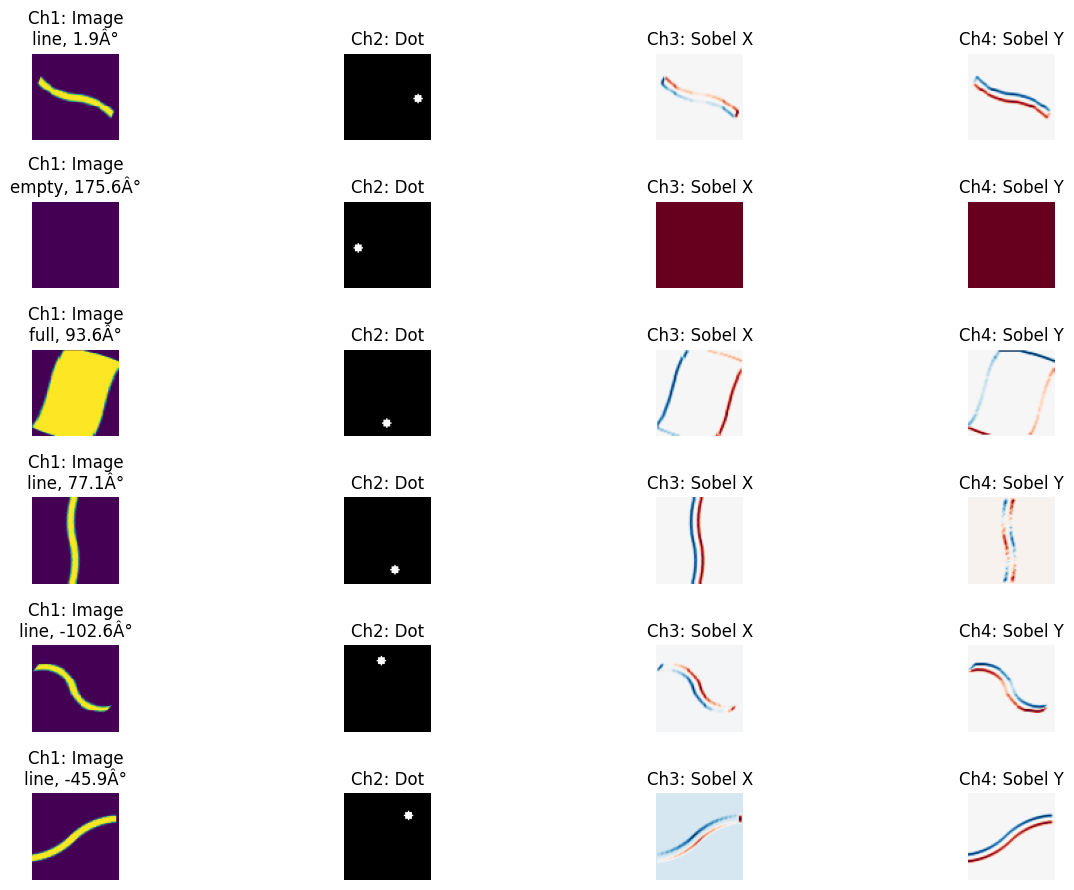

In [9]:
#--------------------------------------------------
# Sanity check: visualize a batch from the dataloader
#--------------------------------------------------

N=6

sample_images, sample_angles, sample_crossings = next(iter(train_dataloader))
print(f"Image batch shape:    {sample_images.shape}")     # [64, 4, 64, 64]
print(f"Angle labels shape:   {sample_angles.shape}")     # [64]
print(f"Crossing labels shape:{sample_crossings.shape}")  # [64]

fig, axes = plt.subplots(N, 4, figsize=(14, 9))
for i in range(N):
    ch = sample_images[i]    # [4, 64, 64]
    crossing_name = IDX_TO_CROSSING[sample_crossings[i].item()]
    angle_deg = math.degrees(sample_angles[i].item())
    axes[i, 0].imshow(ch[0].numpy())
    axes[i, 0].set_title(f"Ch1: Image\n{crossing_name}, {angle_deg:.1f}Â°")
    axes[i, 1].imshow(ch[1].numpy(), cmap='gray')
    axes[i, 1].set_title("Ch2: Dot")
    axes[i, 2].imshow(ch[2].numpy(), cmap='RdBu')
    axes[i, 2].set_title("Ch3: Sobel X")
    axes[i, 3].imshow(ch[3].numpy(), cmap='RdBu')
    axes[i, 3].set_title("Ch4: Sobel Y")
    for ax in axes[i]:
        ax.axis('off')
plt.tight_layout()
plt.show()


In [14]:
#-------------------------------------------------------
# DualHeadKnotNet: 4-channel input, two output heads
#   - Angle head:    outputs [cos(θ), sin(θ)] for circular angle regression
#   - Crossing head: 5-class logits (overcrossing, undercrossing, line, empty, full)
#
# Smaller variant: 4→16→32→64 channels (~1.1M params vs 4.4M original)
#-------------------------------------------------------


''' IMPORTANT TODO: Change the NN so that the angle prediction does not take into account the dot channel. 
However the dot channel is important for '''

class DualHeadKnotNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Shared convolutional backbone — Input: [B, 4, 64, 64]
        self.backbone = nn.Sequential(
            # Block 1
            nn.Conv2d(4, 16, kernel_size=5, padding=2), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),   # 64 → 32

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),   # 32 → 16

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),   # 16 → 8

            nn.Flatten(),      # → [B, 64*8*8] = [B, 4096]
        )

        # Angle head: [cos(θ), sin(θ)] — avoids ±π discontinuity in loss
        self.angle_head = nn.Sequential(
            nn.Linear(4096, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 32),   nn.ReLU(),
            nn.Linear(32, 2),
        )

        # Crossing head: 5-class logits (no Softmax — CrossEntropyLoss handles it)
        self.crossing_head = nn.Sequential(
            nn.Linear(4096, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 32),   nn.ReLU(),
            nn.Linear(32, 5),
        )

    def forward(self, x):
        features     = self.backbone(x)
        angle_out    = self.angle_head(features)     # [B, 2]
        crossing_out = self.crossing_head(features)  # [B, 5]
        return angle_out, crossing_out


model = DualHeadKnotNet()
#print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


# Load existing weights (remove this line to train from scratch)
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "best_model.pth"), weights_only=True ,map_location="cpu"))
model.eval()



Trainable parameters: 1,093,959


DualHeadKnotNet(
  (backbone): Sequential(
    (0): Conv2d(4, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [12]:
#------------------------------
# Loss functions
#------------------------------


# weight between angle loss and crossing loss (Crossing loss is more important)
LAMBDA_ANGLE = 0.25   


#Loss for the angle is the inner product of the unitary vectors
def angle_loss_fn(pred_cs, target_angles, crossing_labels):
    """
    Cosine distance loss on the unit circle.
    Masked for empty(3) and full(4) where angle is not meaningful.

    pred_cs:         [B, 2]  raw [cos, sin] predictions
    target_angles:   [B]     float angles in radians
    crossing_labels: [B]     integer class indices
    """
    mask = (crossing_labels < 3)   # overcrossing(0), undercrossing(1), line(2) only
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred_cs.device, requires_grad=True)

    pred_norm = F.normalize(pred_cs[mask], p=2, dim=1)   # project to unit circle
    target_cs = torch.stack([
        torch.cos(target_angles[mask]),
        torch.sin(target_angles[mask])
    ], dim=1)
    return (1.0 - (pred_norm * target_cs).sum(dim=1)).mean()

#Loss for crossing classifier is a CrossEntropyLoss 
crossing_loss_fn = nn.CrossEntropyLoss()  

def combined_loss(angle_pred, crossing_pred, angle_labels, crossing_labels, lam=LAMBDA_ANGLE):
    a_loss = angle_loss_fn(angle_pred, angle_labels, crossing_labels)
    c_loss = crossing_loss_fn(crossing_pred, crossing_labels)
    total  = lam * a_loss + (1.0 - lam) * c_loss
    return total, a_loss.detach(), c_loss.detach()


In [ ]:
#-----------------------------------------
# Training loop
#-----------------------------------------
def train_loop(dataloader, model, optimizer):
    model.train()
    total_sum, angle_sum, cross_sum = 0.0, 0.0, 0.0

    for X, angle_labels, crossing_labels in dataloader:
        X = X.float()
        angle_pred, crossing_pred = model(X)

        loss, a_loss, c_loss = combined_loss(angle_pred, crossing_pred,
                                              angle_labels, crossing_labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_sum += loss.item()
        angle_sum += a_loss.item()
        cross_sum += c_loss.item()

    n = len(dataloader)
    return total_sum / n, angle_sum / n, cross_sum / n


#-----------------------------------------
# Validation loop
#-----------------------------------------
def val_loop(dataloader, model):
    model.eval()
    total_sum = 0.0
    angle_error_sum = 0.0
    crossing_correct = 0
    n_valid_angle = 0
    n_total = 0

    with torch.no_grad():
        for X, angle_labels, crossing_labels in dataloader:
            X = X.float()
            angle_pred, crossing_pred = model(X)

            loss, _, _ = combined_loss(angle_pred, crossing_pred,
                                       angle_labels, crossing_labels)
            total_sum += loss.item()

            # Crossing accuracy
            crossing_correct += (crossing_pred.argmax(1) == crossing_labels).sum().item()
            n_total += len(crossing_labels)

            # Angle MAE (degrees), only for overcrossing/undercrossing/line
            valid_mask = (crossing_labels < 3)
            if valid_mask.sum() > 0:
                pred_angles = torch.atan2(angle_pred[valid_mask, 1],
                                          angle_pred[valid_mask, 0])
                true_angles = angle_labels[valid_mask]
                # Wrapped angular difference to handle Â±Ï€ boundary
                diff = torch.atan2(torch.sin(pred_angles - true_angles),
                                   torch.cos(pred_angles - true_angles))
                angle_error_sum += diff.abs().sum().item() * (180.0 / math.pi)
                n_valid_angle += valid_mask.sum().item()

    n_batches = len(dataloader)
    mean_angle_err = angle_error_sum / max(n_valid_angle, 1)
    crossing_acc   = crossing_correct / max(n_total, 1)
    val_loss       = total_sum / n_batches
    print(f"  Val: loss={val_loss:.4f}  crossing_acc={100*crossing_acc:.1f}%  angle_MAE={mean_angle_err:.2f}Â°")
    return val_loss


#-----------------------------------------
# Main training run
#-----------------------------------------
learning_rate = 0.001
epochs = 40

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

best_val_loss = float("inf")

for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}")
    train_total, train_angle, train_cross = train_loop(train_dataloader, model, optimizer)
    print(f"  Train: total={train_total:.4f}  angle={train_angle:.4f}  crossing={train_cross:.4f}")
    val_loss = val_loop(val_dataloader, model)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "best_model.pth"))
        print(f"  --> Saved best model (val_loss={val_loss:.4f})")

print("Done!")

In [13]:
#---------------------------------------------------------------------------------------------
# DrawerApp to test with the trained dual-head model
#---------------------------------------------------------------------------------------------

import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageDraw
import numpy as np

# Indicator dot scaled from 64x64 dot-channel logic to the 280x280 canvas
_CANVAS_SIZE        = 280
_DOT_INDICATOR_R    = int(DOT_RADIUS_FROM_CENTER * _CANVAS_SIZE / WINDOW_SIZE[0])  # ~96 px from center
_DOT_INDICATOR_SIZE = 10   # visual half-size of the red indicator circle (px)


def prepare_for_nn(crop_gray_np, traversal_angle):
    """
    Builds a [1, 4, 64, 64] tensor from a grayscale crop and a traversal angle.
    crop_gray_np: float32 [64, 64] in [0, 1]
    traversal_angle: float, radians
    """
    dot_np = make_dot_channel(traversal_angle)
    sobel_x, sobel_y = compute_sobel_channels(crop_gray_np)

    ch1 = torch.from_numpy(crop_gray_np).unsqueeze(0)
    ch2 = torch.from_numpy(dot_np).unsqueeze(0)
    ch3 = torch.from_numpy(sobel_x).unsqueeze(0)
    ch4 = torch.from_numpy(sobel_y).unsqueeze(0)
    image_tensor = torch.cat([ch1, ch2, ch3, ch4], dim=0)   # [4, 64, 64]

    image_tensor[0] = (image_tensor[0] - 0.5) / 0.5
    image_tensor[1] = (image_tensor[1] - 0.5) / 0.5
    image_tensor[2] = image_tensor[2] * 5.0
    image_tensor[3] = image_tensor[3] * 5.0

    return image_tensor.unsqueeze(0).float()   # [1, 4, 64, 64]


class DrawerApp:
    def __init__(self, model):
        self.model = model
        self.root = tk.Tk()
        self.root.title("Dual-Head Knot Classifier")

        self.canvas = tk.Canvas(self.root, width=_CANVAS_SIZE, height=_CANVAS_SIZE, bg='white')
        self.canvas.grid(row=0, column=0, columnspan=3)

        self.image = Image.new("L", (_CANVAS_SIZE, _CANVAS_SIZE), "white")
        self.draw  = ImageDraw.Draw(self.image)

        self.canvas.bind("<B1-Motion>", self.paint)

        # Angle entry
        tk.Label(self.root, text="Traversal angle (°):").grid(row=1, column=0, sticky='e')
        self.angle_var = tk.StringVar(value="0")
        tk.Entry(self.root, textvariable=self.angle_var, width=8).grid(row=1, column=1, sticky='w')
        self.angle_var.trace_add("write", self._on_angle_change)

        # Buttons
        tk.Button(self.root, text="Classify", command=self.classify).grid(row=2, column=0)
        tk.Button(self.root, text="Clear",    command=self.clear).grid(row=2, column=1)

        # Result label
        self.result_var = tk.StringVar(value="Draw something and click Classify")
        tk.Label(self.root, textvariable=self.result_var, font=("Arial", 11)).grid(row=3, column=0, columnspan=3, pady=4)

        self._update_angle_dot(0.0)

    def _on_angle_change(self, *args):
        try:
            angle_rad = math.radians(float(self.angle_var.get()))
        except ValueError:
            return
        self._update_angle_dot(angle_rad)

    def _update_angle_dot(self, angle_rad):
        """Redraw the red direction indicator dot on the canvas."""
        self.canvas.delete("angle_dot")
        cx = cy = _CANVAS_SIZE // 2
        x = cx + int(round(_DOT_INDICATOR_R * math.cos(angle_rad)))
        y = cy + int(round(_DOT_INDICATOR_R * math.sin(angle_rad)))
        self.canvas.create_oval(
            x - _DOT_INDICATOR_SIZE, y - _DOT_INDICATOR_SIZE,
            x + _DOT_INDICATOR_SIZE, y + _DOT_INDICATOR_SIZE,
            fill="red", outline="darkred", tags="angle_dot",
        )

    def paint(self, event):
        x1, y1 = event.x - 8, event.y - 8
        x2, y2 = event.x + 8, event.y + 8
        self.canvas.create_oval(x1, y1, x2, y2, fill="black", width=12)
        self.draw.ellipse([x1, y1, x2, y2], fill="black")

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (_CANVAS_SIZE, _CANVAS_SIZE), "white")
        self.draw  = ImageDraw.Draw(self.image)
        self.result_var.set("Draw something and click Classify")
        self._on_angle_change()  # restore indicator after full canvas wipe

    def classify(self):
        try:
            angle_deg = float(self.angle_var.get())
        except ValueError:
            self.result_var.set("Invalid angle — enter a number in degrees")
            return

        traversal_angle = math.radians(angle_deg)

        img_resized = self.image.resize((64, 64))
        img_array   = np.array(img_resized, dtype=np.float32)
        img_array   = 1.0 - (img_array / 255.0)   # invert: white bg → 0, drawn lines → 1

        input_tensor = prepare_for_nn(img_array, traversal_angle)
        
        #plt.imshow(img_array)
        #plt.show()

        self.model.eval()
        with torch.no_grad():
            angle_out, crossing_out = self.model(input_tensor)

        pred_angle_rad  = math.atan2(angle_out[0, 1].item(), angle_out[0, 0].item())
        pred_angle_deg  = math.degrees(pred_angle_rad)
        crossing_idx    = crossing_out.argmax(1).item()
        crossing_name   = IDX_TO_CROSSING[crossing_idx]
        crossing_probs  = torch.softmax(crossing_out, dim=1)[0]
        confidence      = crossing_probs[crossing_idx].item() * 100

        self.result_var.set(
            f"Crossing: {crossing_name} ({confidence:.1f}%)  |  Angle: {pred_angle_deg:.1f}°"
        )

    def run(self):
        self.root.mainloop()


app = DrawerApp(model)
app.run()